# K-Fold for each model

In [8]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())
from minilearn.helper import ezcols
from minilearn.preprocessing.test_train_splitfunc import train_test_split
from minilearn.preprocessing.Scaler import StandardScalerMM
from minilearn.preprocessing.test_train_splitfunc import train_test_split
from minilearn.classifiers.logisiticRegressionFunc import LogisticRegressionMM
from minilearn.classifiers.KNN import KNNClassifierMM
from minilearn.classifiers.NBG import GaussianNaiveBayesMM
from minilearn.classifiers.SVM import SVMMM
from minilearn.classifiers.CART import CART
from minilearn.metrics.metricss import accuracy, precision, recall, f1_score
from minilearn.kfold import k_fold_split


Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


In [9]:
features = pd.read_csv("data/processed/features.csv")

print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


In [10]:
feature_cols = ezcols()

X = features[feature_cols].values
y = features["emotion"].values

print("X:", X.shape)
print("y:", y.shape)

X: (2451, 480)
y: (2451,)


In [19]:
def run_kfold(model_factory, X, y, k=5, random_state=20):
    """
    model_factory: zero-arg callable that returns a fresh, unfit model
    Returns a dict with per-fold and mean metrics.
    """
    folds = k_fold_split(X, y, k=k, shuffle=True, random_state=random_state)
    labels = list(np.unique(y))
    
    acc_list, prec_list, rec_list, f1_list, time_list = [], [], [], [], []
    
    for fold_num, (train_idx, test_idx) in enumerate(folds):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        # scaler fit on training fold only -- no leakage
        scaler = StandardScalerMM()
        scaler.fit(X_tr)
        X_tr_s = scaler.transform(X_tr)
        X_te_s = scaler.transform(X_te)
        
        model = model_factory()
        model.fit(X_tr_s, y_tr)
        
        y_pred = model.predict(X_te_s)
        
        acc_list.append(accuracy(y_te, y_pred))
        prec_list.append(precision(y_te, y_pred, labels, average='macro'))
        rec_list.append(recall(y_te, y_pred, labels, average='macro'))
        f1_list.append(f1_score(y_te, y_pred, labels, average='macro'))
    
    return {
        'accuracy_mean': np.mean(acc_list),
        'accuracy_std':  np.std(acc_list),
        'precision_mean': np.mean(prec_list),
        'recall_mean':   np.mean(rec_list),
        'f1_mean':       np.mean(f1_list),
        'f1_std':        np.std(f1_list),
        'train_time_mean': np.mean(time_list),
        'per_fold_acc':  acc_list,
        'per_fold_f1':   f1_list,
    }

In [21]:
K = 5
RS = 20

results = {}

print("Running Logistic Regression...")
results['LR (MiniLearn)'] = run_kfold(lambda: LogisticRegressionMM(lr=0.1, n_iters=1000), X, y, k=K, random_state=RS)

print("Running Gaussian NB...")
results['NB (MiniLearn)'] = run_kfold(lambda: GaussianNaiveBayesMM(), X, y, k=K, random_state=RS)

print("Running KNN (k=5)...")
results['KNN (MiniLearn)'] = run_kfold(lambda: KNNClassifierMM(k=5), X, y, k=K, random_state=RS)

print("Running SVM (linear)...")
results['SVM (MiniLearn)'] = run_kfold(lambda: SVMMM(C=1.0, learning=0.001, max_iters=1000), X, y, k=K, random_state=RS)

print("Running CART (max_depth=5, on 30% subset for speed)...")
rng = np.random.default_rng(20)
sub_idx = rng.choice(len(X), size=int(0.1 * len(X)), replace=False)
X_sub, y_sub = X[sub_idx], y[sub_idx]
results['CART (MiniLearn, 10% subset)'] = run_kfold(
    lambda: CART(max_depth=5, minsplit=2), X_sub, y_sub, k=K, random_state=RS
)

print("\nDone.")

Running Logistic Regression...
Running Gaussian NB...
Running KNN (k=5)...
Running SVM (linear)...
Running CART (max_depth=5, on 30% subset for speed)...

Done.


In [22]:
# Build summary table
rows = []
for name, r in results.items():
    rows.append({
        'Model': name,
        'Acc (mean)':  f"{r['accuracy_mean']:.4f}",
        'Acc (std)':   f"{r['accuracy_std']:.4f}",
        'Precision':   f"{r['precision_mean']:.4f}",
        'Recall':      f"{r['recall_mean']:.4f}",
        'F1 (macro)':  f"{r['f1_mean']:.4f}",
        'F1 (std)':    f"{r['f1_std']:.4f}",
        'Train time (s)': f"{r['train_time_mean']:.3f}",
    })

cv_df = pd.DataFrame(rows)
cv_df

,Model,Acc (mean),Acc (std),Precision,Recall,F1 (macro),F1 (std),Train time (s)
0,LR (MiniLearn),0.7319,0.0116,0.7267,0.7268,0.7254,0.0170,nan
1,NB (MiniLearn),0.2717,0.0134,0.2649,0.2924,0.2004,0.0189,nan
2,KNN (MiniLearn),0.5965,0.0056,0.5995,0.5753,0.5758,0.0105,nan
3,SVM (MiniLearn),0.2325,0.0119,0.1208,0.1895,0.1141,0.0085,nan
4,"CART (MiniLearn, 10% subset)",0.3337,0.0671,0.3489,0.3253,0.3151,0.0561,nan


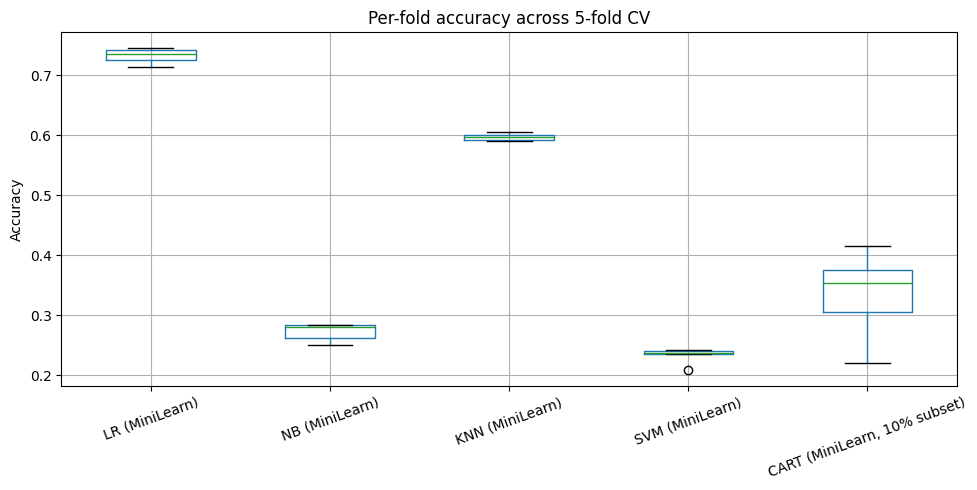

In [23]:
# Per-fold accuracy plot to visualize the spread
fig, ax = plt.subplots(figsize=(10, 5))
fold_data = pd.DataFrame({name: r['per_fold_acc'] for name, r in results.items()})
fold_data.boxplot(ax=ax)
ax.set_title("Per-fold accuracy across 5-fold CV")
ax.set_ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()